In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
with open('Thal_power2_laplace.p','rb') as f:
    power_dict_thal = pickle.load(f)

with open('Thal_size2_laplace.p','rb') as f:
    size_dict_thal = pickle.load(f)   

In [3]:
with open('LBX_power2_laplace.p','rb') as f:
    power_dict_lbx = pickle.load(f)

with open('LBXv2_power2_laplace.p','rb') as f:
    power_dict_lbx_2 = pickle.load(f)

with open('LBX_size2_laplace.p','rb') as f:
    size_dict_lbx = pickle.load(f)   

In [4]:
with open('BR283_power2_laplace.p','rb') as f:
    power_dict_br283 = pickle.load(f)

with open('BR283v2_power2_laplace.p','rb') as f:
    power_dict_br283_2 = pickle.load(f)

In [11]:
power_dict_lbx[25] = power_dict_lbx_2[25]
power_dict_lbx[30] = power_dict_lbx_2[30]
power_dict_br283[20] = power_dict_br283_2[20]
power_dict_br283[22] = power_dict_br283_2[22]


In [15]:
ssize = 5*(np.arange(6)+1)
ssize2 = np.array([5,10,15,20,22])

In [19]:
power_list_thal = np.array([power_dict_thal[d]['power'] for d in power_dict_thal.keys()])
power_list_br283 = np.array([power_dict_br283[d]['power'] for d in power_dict_br283.keys()])
power_list_lbx = np.array([power_dict_lbx[d]['power'] for d in power_dict_lbx.keys()])

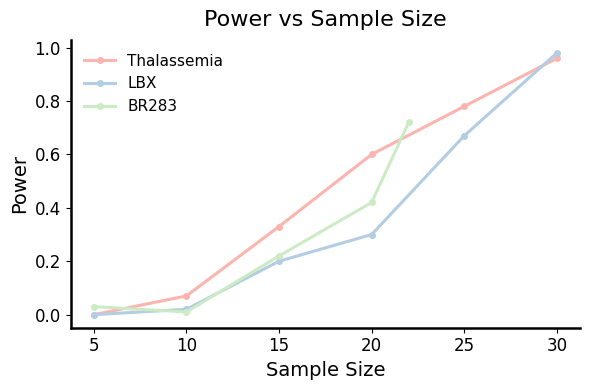

In [37]:
import matplotlib.pyplot as plt

# Global styling aligned with your preferences
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.8,        # thicker spines (bottom/left)
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

fig, ax = plt.subplots(figsize=(6, 4))

# Pastel colors via a built-in pastel colormap
pastel = plt.get_cmap("Pastel1")
c0, c1, c2 = pastel(0), pastel(1), pastel(2)

ax.plot(ssize,  power_list_thal, label="Thalassemia", linewidth=2.2, marker="o", markersize=4, color=c0)
ax.plot(ssize,  power_list_lbx,  label="LBX",         linewidth=2.2, marker="o", markersize=4, color=c1)
ax.plot(ssize2, power_list_br283, label="BR283",      linewidth=2.2, marker="o", markersize=4, color=c2)

ax.set_xlabel("Sample Size")
ax.set_ylabel("Power")
ax.set_title("Power vs Sample Size", pad=10)

# Clean, readable grid and legend placement
#ax.grid(True, which="major", linewidth=0.8, alpha=0.35)
ax.legend(loc="upper left", frameon=False)

fig.tight_layout()
plt.show()


In [40]:
arr_1 = np.concatenate((np.array(size_dict_thal[12]['per_group'][0]['pvals']),
                        np.array(size_dict_thal[12]['per_group'][1]['pvals'])))

arr_2 = np.concatenate((np.array(size_dict_thal[20]['per_group'][0]['pvals']),
                        np.array(size_dict_thal[20]['per_group'][1]['pvals'])))

arr_3 = np.array(size_dict_lbx[12]['per_group'][0]['pvals'])

arr_4 = np.array(size_dict_lbx[20]['per_group'][0]['pvals'])


In [59]:
print(np.mean(arr_1<.05))
print(np.mean(arr_2<.05))
print(np.mean(arr_3<.05))
print(np.mean(arr_4<.05))

0.044
0.032
0.024
0.01


/var/folders/k4/8f7w5xpd05v9x_bwsy54mh8r0000gn/T/ipykernel_69795/2820688628.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


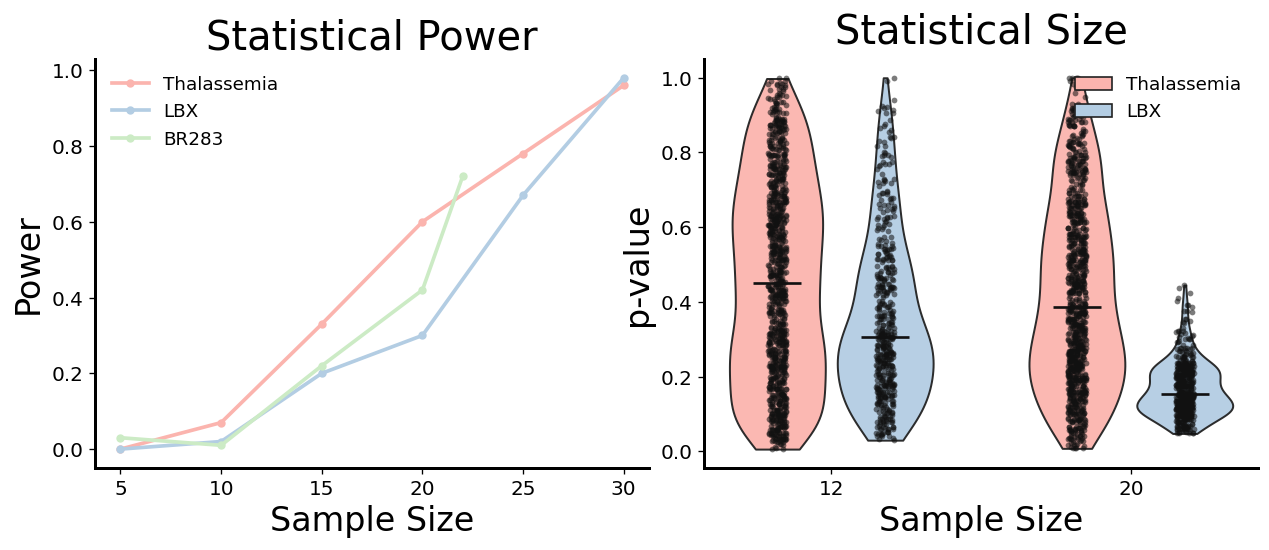

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Global styling aligned with your preferences
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.8,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

# Shared pastel palette (match prior plot)
pastel = plt.get_cmap("Pastel1")
c_thal, c_lbx, c_br283 = pastel(0), pastel(1), pastel(2)

# Create side-by-side figure
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12.5, 4.6),
    dpi=120,
    gridspec_kw={"wspace": 0.1}
)

# -------- Left panel: line plot --------
ax1.plot(ssize,  power_list_thal,  label="Thalassemia", linewidth=2.2, marker="o", markersize=4, color=c_thal)
ax1.plot(ssize,  power_list_lbx,   label="LBX",         linewidth=2.2, marker="o", markersize=4, color=c_lbx)
ax1.plot(ssize2, power_list_br283, label="BR283",       linewidth=2.2, marker="o", markersize=4, color=c_br283)

ax1.set_xlabel("Sample Size",fontsize=20)
ax1.set_ylabel("Power",fontsize=20)
ax1.set_title("Statistical Power",fontsize=24)
ax1.grid(False)
ax1.legend(loc="upper left", frameon=False)

# -------- Right panel: violin plot --------
data = [arr_1, arr_2, arr_3, arr_4]
group = ["12", "20", "12", "20"]
subtype = ["Thalassemia", "Thalassemia", "LBX", "LBX"]

fill_by_subtype = {"Thalassemia": c_thal, "LBX": c_lbx}

base_x = {"12": 1.0, "20": 2.0}
offset = {"Thalassemia": -0.18, "LBX": 0.18}
positions = [base_x[g] + offset[s] for g, s in zip(group, subtype)]

vp = ax2.violinplot(
    data,
    positions=positions,
    widths=0.32,
    showmeans=False,
    showmedians=True,
    showextrema=False
)

for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(fill_by_subtype[subtype[i]])
    body.set_edgecolor("#222222")
    body.set_linewidth(1.2)
    body.set_alpha(0.95)

vp["cmedians"].set_color("#111111")
vp["cmedians"].set_linewidth(1.6)

# Keep black dots (jittered)
rng = np.random.default_rng(0)
for x, y in zip(positions, data):
    y = np.asarray(y)
    jitter = rng.uniform(-0.03, 0.03, size=y.size)
    ax2.scatter(np.full(y.size, x) + jitter, y, s=12, alpha=0.55, linewidths=0, color="#111111")

ax2.grid(False)
ax2.set_xticks([1.0, 2.0])
ax2.set_xticklabels(["12", "20"])
ax2.set_xlabel("Sample Size",fontsize=20)
ax2.set_ylabel("p-value",fontsize=20)
ax2.set_title("Statistical Size", pad=10,fontsize=24)

handles = [
    Patch(facecolor=fill_by_subtype["Thalassemia"], edgecolor="#222222", label="Thalassemia"),
    Patch(facecolor=fill_by_subtype["LBX"], edgecolor="#222222", label="LBX"),
]
ax2.legend(handles=handles, loc="upper right", frameon=False)

fig.tight_layout()
fig.subplots_adjust(bottom=0.14)
plt.savefig("PowerSizeFig.pdf")

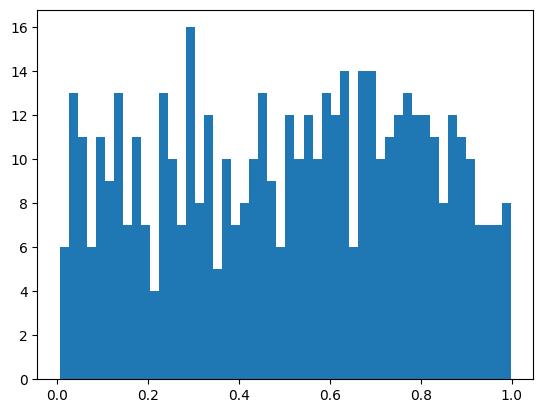

In [29]:
plt.hist(np.array(size_dict_thal[12]['per_group'][0]['pvals']),50);

In [16]:
ssize

array([ 5, 10, 15, 20, 25, 30])

In [13]:
power_dict_br283.keys()

dict_keys([5, 10, 15, 20, 22])

In [8]:
for key in power_dict_thal[5].keys():
    print(key,type(power_dict_thal[5][key]))

power <class 'float'>
se <class 'numpy.float64'>
n0 <class 'int'>
n1 <class 'int'>
valid_trials <class 'int'>


In [10]:
for key in power_dict_thal.keys():
    print(key,power_dict_thal[key]['power'])

5 0.0
10 0.07
15 0.33
20 0.6
25 0.78
30 0.96


In [17]:
power_dict_br283_2.keys()

dict_keys([20, 22])

In [18]:
power_dict_br283[20] = power_dict_br283_2[20]
power_dict_br283[22] = power_dict_br283_2[22]

In [11]:
size_dict_thal.keys()

dict_keys([12, 20])

In [12]:
for key in size_dict_thal[12].keys():
    print(key,type(size_dict_thal[12][key]))

fpr <class 'float'>
se <class 'float'>
per_group <class 'dict'>


In [13]:
size_dict_thal[20]['fpr']

0.032

In [14]:
size_dict_thal[12]['fpr']

0.044

In [15]:
print(size_dict_lbx[12]['fpr'])
print(size_dict_lbx[20]['fpr'])

0.024
0.01


In [16]:
for key in power_dict_lbx.keys():
    print(key,power_dict_lbx[key]['power'])

5 0.0
10 0.02
15 0.2
20 0.3
25 0.67
30 0.98


In [19]:
for key in power_dict_br283.keys():
    print(key,power_dict_br283[key]['power'])

5 0.03
10 0.01
15 0.22
20 0.42
22 0.72


In [21]:
import numpy as np
import pandas as pd
import pickle

from batchdetect.loader import load_br283_cross_lot_covs
from batchdetect.mixture import HeavyMixture,parametric_bootstrap_lrt

df_thal_likelihoods = pd.read_csv('../likelihoods_br283.csv')
snames = df_thal_likelihoods['Sample Name'].values
likelihoods = df_thal_likelihoods['Likelihood'].values
y_hat = df_thal_likelihoods['Label'].values

counts_thal,y_thal,sample_id,features,_ = load_br283_cross_lot_covs()

index_homozygous_del = [12,13,14]
counts_thal_new = np.delete(counts_thal, index_homozygous_del, axis=0)
likelihoods_new = np.delete(likelihoods, index_homozygous_del)
y_new = np.delete(y_hat, index_homozygous_del)
snames_new = np.delete(snames,index_homozygous_del)

ModuleNotFoundError: No module named 'simulation3'